# Top Cuisines

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Rushii\OneDrive\Documents\Cofnifyz intern\Dataset adjust.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
cuisine_counts = (
    df['Cuisines']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

top3 = cuisine_counts.head(3)

print(top3)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [7]:
total_restaurants = len(df)

percentage = (top3 / total_restaurants) * 100

print(percentage)

Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


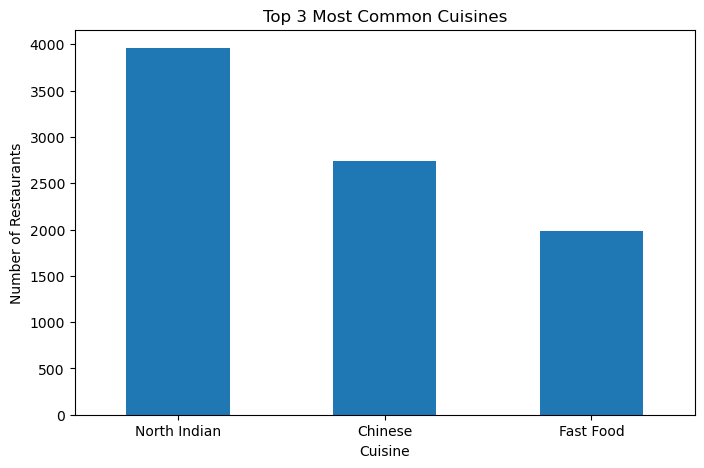

In [8]:
plt.figure(figsize=(8,5))

top3.plot(kind='bar')

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)

plt.show()

# City Analysis

In [9]:
df['City'].head()

0         Makati City
1         Makati City
2    Mandaluyong City
3    Mandaluyong City
4    Mandaluyong City
Name: City, dtype: object

In [10]:
city_count = df['City'].value_counts()

print(city_count)

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64


In [11]:
print("City with the highest num of restuarants:")
print(city_count.head(1))

City with the highest num of restuarants:
City
New Delhi    5473
Name: count, dtype: int64


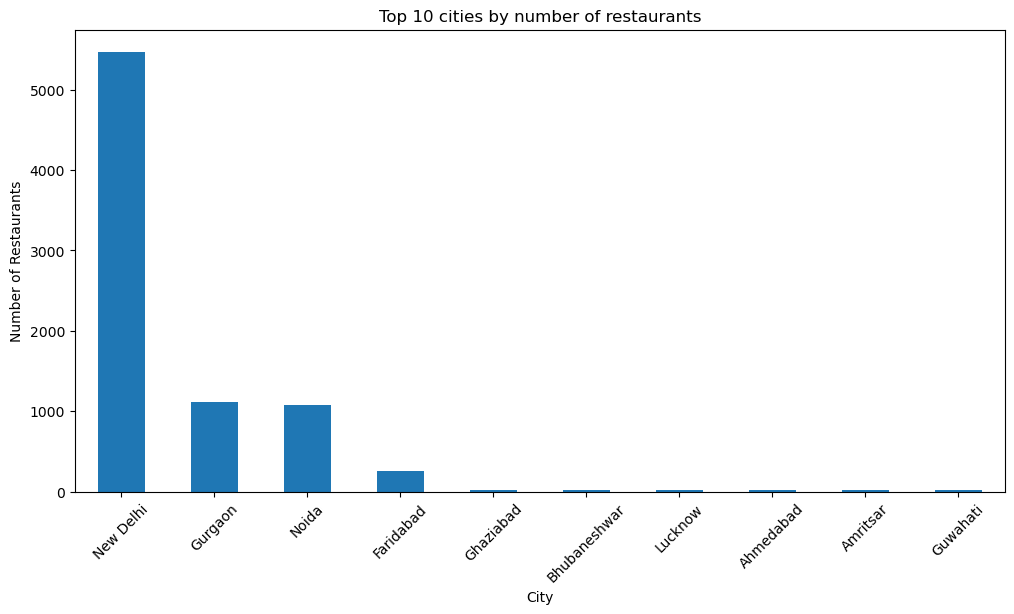

In [12]:
plt.figure(figsize=(12,6))
city_count.head(10).plot(kind='bar')

plt.title("Top 10 cities by number of restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

plt.show()


In [13]:
city_rating = df.groupby('City')['Aggregate rating'].mean()
print(city_rating)

City
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
Allahabad          3.395000
                     ...   
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
��stanbul          4.292857
Name: Aggregate rating, Length: 141, dtype: float64


In [14]:
city_rating = city_rating.sort_values(ascending=False)
print(city_rating)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


In [15]:
print("City with Highest Average Rating:")
print(city_rating.head(1))

City with Highest Average Rating:
City
Inner City    4.9
Name: Aggregate rating, dtype: float64


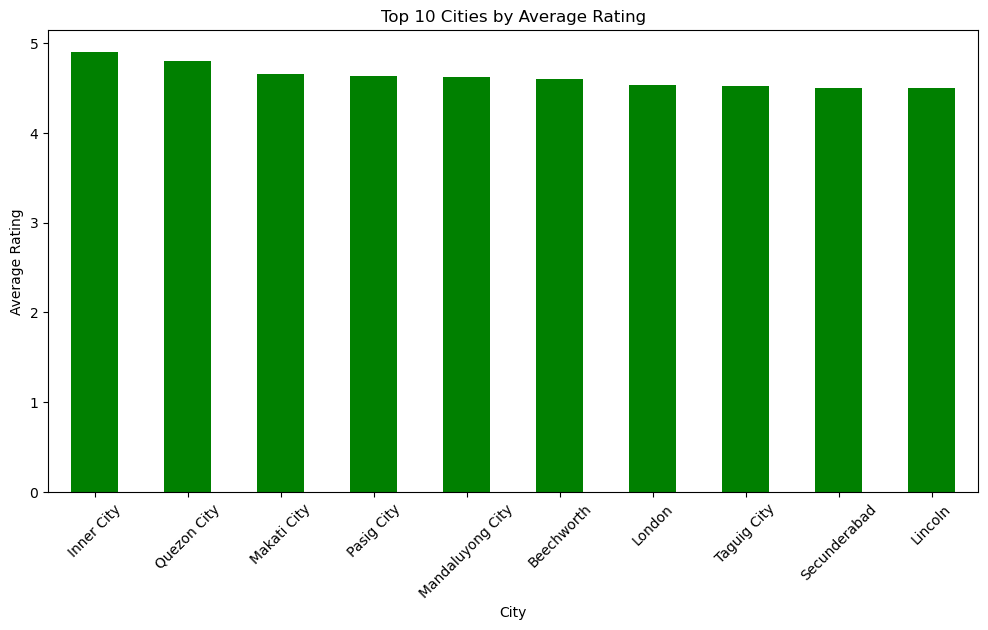

In [16]:
plt.figure(figsize=(12,6))

city_rating.head(10).plot(kind='bar', color='green')

plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.show()

# Price Range Distribution

In [17]:
df['Price range'].head()

0    3
1    3
2    4
3    4
4    4
Name: Price range, dtype: int64

In [18]:
price_count = df['Price range'].value_counts().sort_index()

print(price_count)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [19]:
price_percentage = (price_count / len(df)) * 100

print(price_percentage)

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


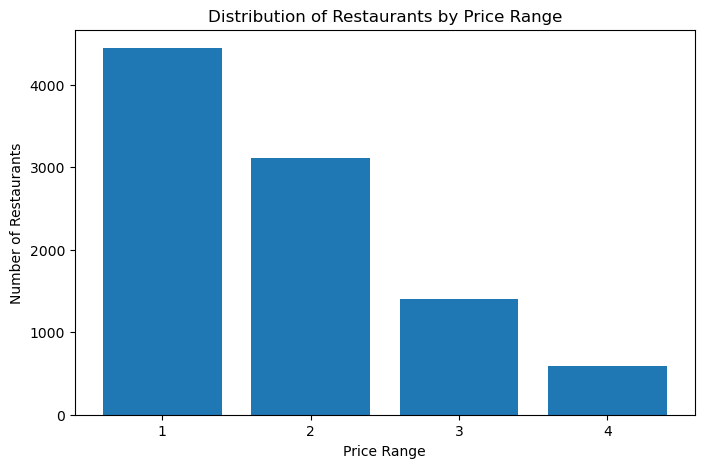

In [20]:
plt.figure(figsize=(8,5))

plt.bar(price_count.index, price_count.values)

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.xticks(price_count.index)

plt.show()

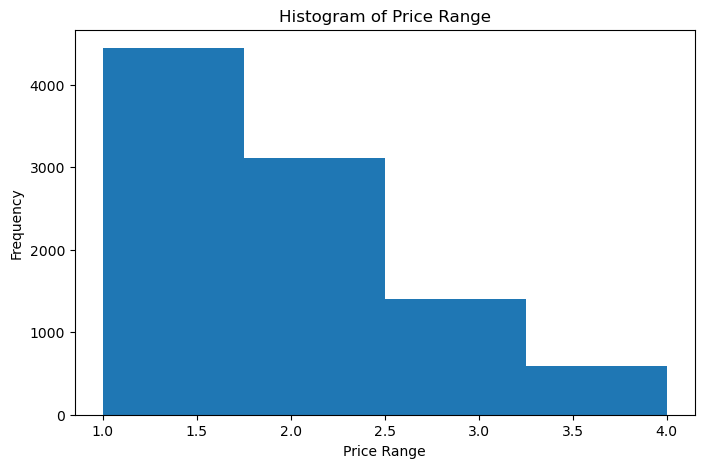

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df['Price range'], bins=4)

plt.title("Histogram of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Frequency")

plt.show()

In [22]:
price_summary = pd.DataFrame({
    'Restaurant Count': price_count,
    'Percentage': price_percentage.round(2)
})

print(price_summary)

             Restaurant Count  Percentage
Price range                              
1                        4444       46.53
2                        3113       32.59
3                        1408       14.74
4                         586        6.14


# Online Delivery Analysis

In [23]:
df['Has Online delivery'].head()

0    No
1    No
2    No
3    No
4    No
Name: Has Online delivery, dtype: object

In [24]:
online_delivery_count = df['Has Online delivery'].value_counts()

print(online_delivery_count)

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64


In [25]:
online_delivery_percentage = (
    df['Has Online delivery']
    .value_counts(normalize=True) * 100
)

print(online_delivery_percentage)

Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


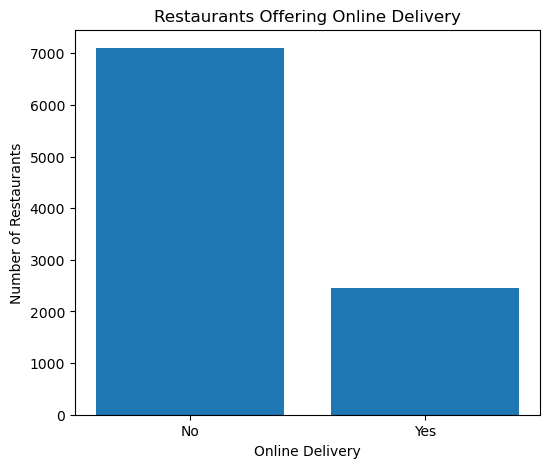

In [26]:
plt.figure(figsize=(6,5))

plt.bar(
    online_delivery_count.index,
    online_delivery_count.values
)

plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")

plt.show()

In [27]:
average_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()

print(average_rating)

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


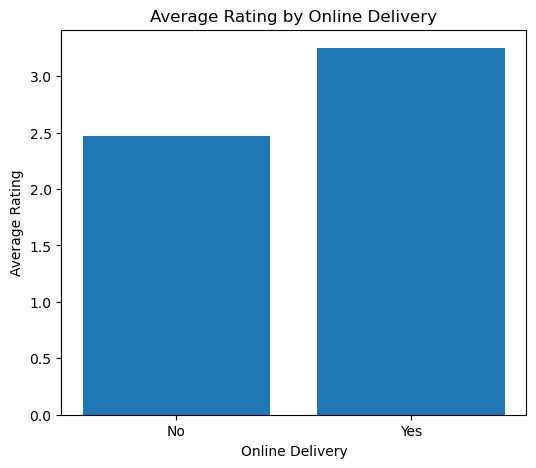

In [28]:
plt.figure(figsize=(6,5))

plt.bar(
    average_rating.index,
    average_rating.values
)

plt.title("Average Rating by Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

plt.show()

In [29]:
summary = pd.DataFrame({
    "Restaurant Count": online_delivery_count,
    "Percentage": online_delivery_percentage.round(2),
    "Average Rating": average_rating
})

print(summary)

                     Restaurant Count  Percentage  Average Rating
Has Online delivery                                              
No                               7100       74.34        2.465296
Yes                              2451       25.66        3.248837


# Restaurant Ratings Analysis

In [30]:
df[['Aggregate rating', 'Votes']].head()

,Aggregate rating,Votes
0,4.8,314
1,4.5,591
2,4.4,270
3,4.9,365
4,4.8,229


In [31]:
df['Aggregate rating'].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

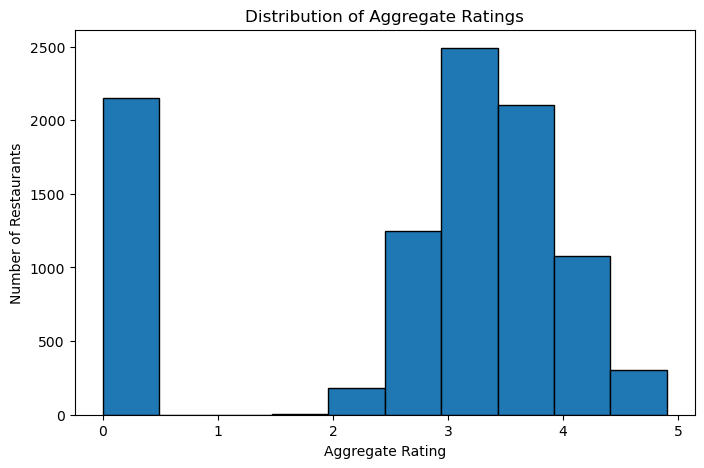

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df['Aggregate rating'], bins=10, edgecolor='black')

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.show()

In [33]:
rating_count = df['Aggregate rating'].value_counts().sort_index()

print(rating_count)

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


In [34]:
most_common_rating = df['Aggregate rating'].mode()

print("Most Common Rating:")
print(most_common_rating)

Most Common Rating:
0    0.0
Name: Aggregate rating, dtype: float64


In [35]:
rating_range = pd.cut(
    df['Aggregate rating'],
    bins=[0,1,2,3,4,5],
    labels=['0-1','1-2','2-3','3-4','4-5']
)

rating_distribution = rating_range.value_counts().sort_index()

print(rating_distribution)

Aggregate rating
0-1       0
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64


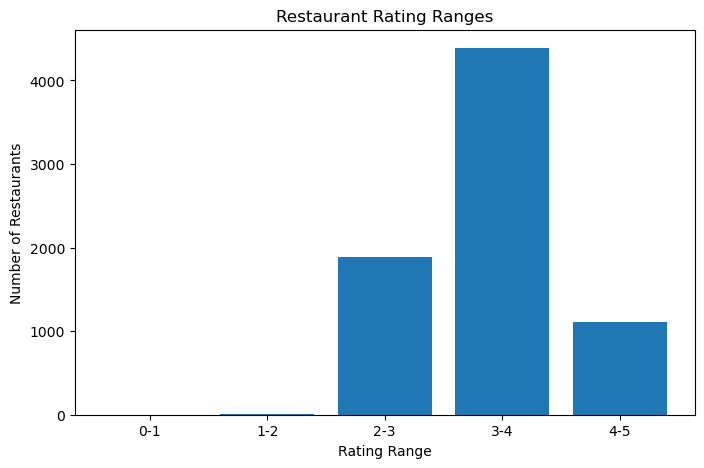

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    rating_distribution.index.astype(str),
    rating_distribution.values
)

plt.title("Restaurant Rating Ranges")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")

plt.show()

In [37]:
average_votes = df['Votes'].mean()

print("Average Votes:", round(average_votes,2))

Average Votes: 156.91


In [38]:
print("Average Rating:", round(df['Aggregate rating'].mean(),2))
print("Average Votes:", round(df['Votes'].mean(),2))

Average Rating: 2.67
Average Votes: 156.91


# Cuisine Combination Analysis

In [39]:
df[['Cuisines', 'Aggregate rating']].head()

,Cuisines,Aggregate rating
0,"French, Japanese, Desserts",4.8
1,Japanese,4.5
2,"Seafood, Asian, Filipino, Indian",4.4
3,"Japanese, Sushi",4.9
4,"Japanese, Korean",4.8


In [40]:
df['Cuisines'].isnull().sum()

np.int64(9)

In [41]:
df = df.dropna(subset=['Cuisines'])

In [42]:
cuisine_combination = df['Cuisines'].value_counts()

print(cuisine_combination.head(10))

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [43]:
top10_combination = cuisine_combination.head(10)

print(top10_combination)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


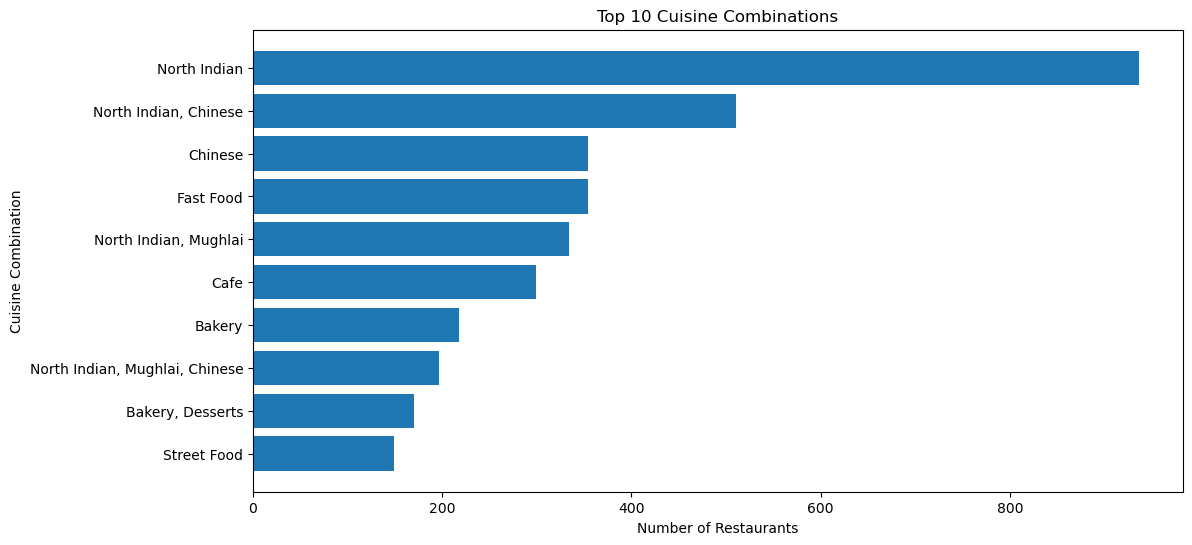

In [44]:
plt.figure(figsize=(12,6))

plt.barh(top10_combination.index, top10_combination.values)

plt.title("Top 10 Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")

plt.gca().invert_yaxis()

plt.show()

In [45]:
avg_rating = df.groupby('Cuisines')['Aggregate rating'].mean()

In [46]:
avg_rating = avg_rating.sort_values(ascending=False)

print(avg_rating.head(10))

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


In [47]:
popular_cuisine = df.groupby('Cuisines').filter(lambda x: len(x) >= 5)

In [48]:
popular_rating = (
    popular_cuisine
    .groupby('Cuisines')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

print(popular_rating.head(10))

Cuisines
North Indian, European, Mediterranean    4.460000
Burger                                   4.450000
Modern Indian                            4.345455
Indian                                   4.250000
International                            4.233333
Italian, Pizza, Sandwich                 4.220000
French                                   4.185714
Steak                                    4.185714
Cafe, Bakery, Desserts                   4.166667
Cafe, Italian, Continental               4.150000
Name: Aggregate rating, dtype: float64


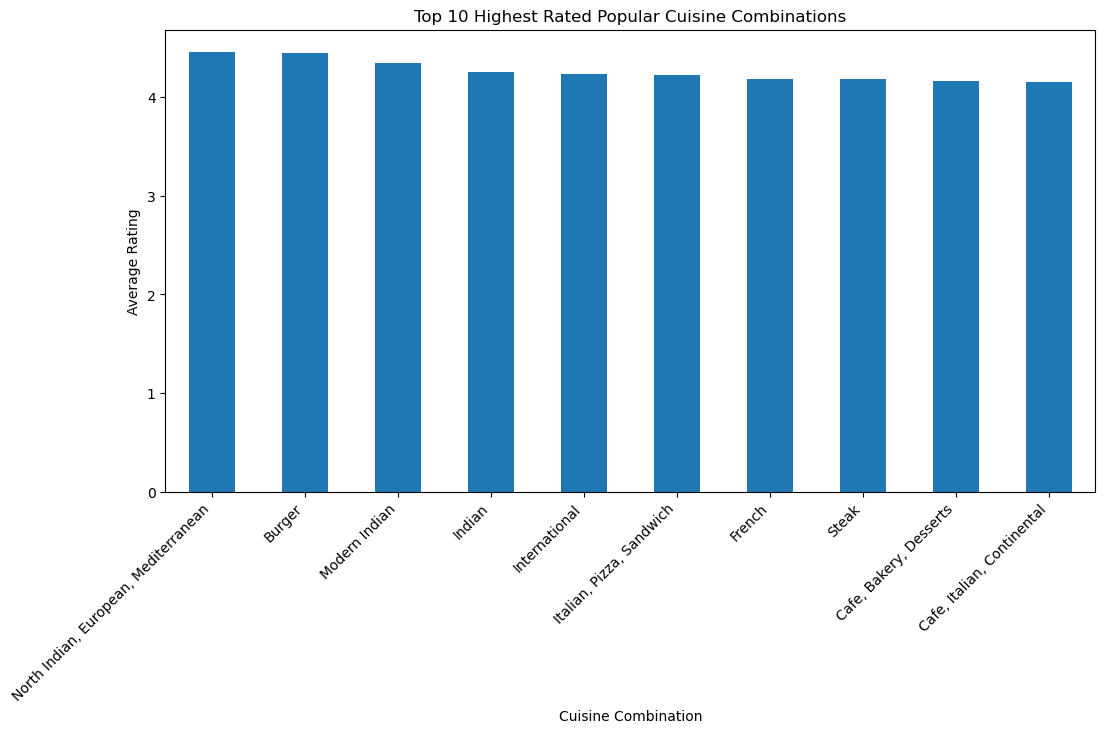

In [49]:
plt.figure(figsize=(12,6))

popular_rating.head(10).plot(kind='bar')

plt.title("Top 10 Highest Rated Popular Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")

plt.xticks(rotation=45, ha='right')

plt.show()

# Geographic Analysis

In [50]:
df[['Latitude', 'Longitude']].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


In [51]:
df[['Latitude', 'Longitude']].isnull().sum()

Latitude     0
Longitude    0
dtype: int64

In [52]:
geo_df = df.dropna(subset=['Latitude', 'Longitude'])

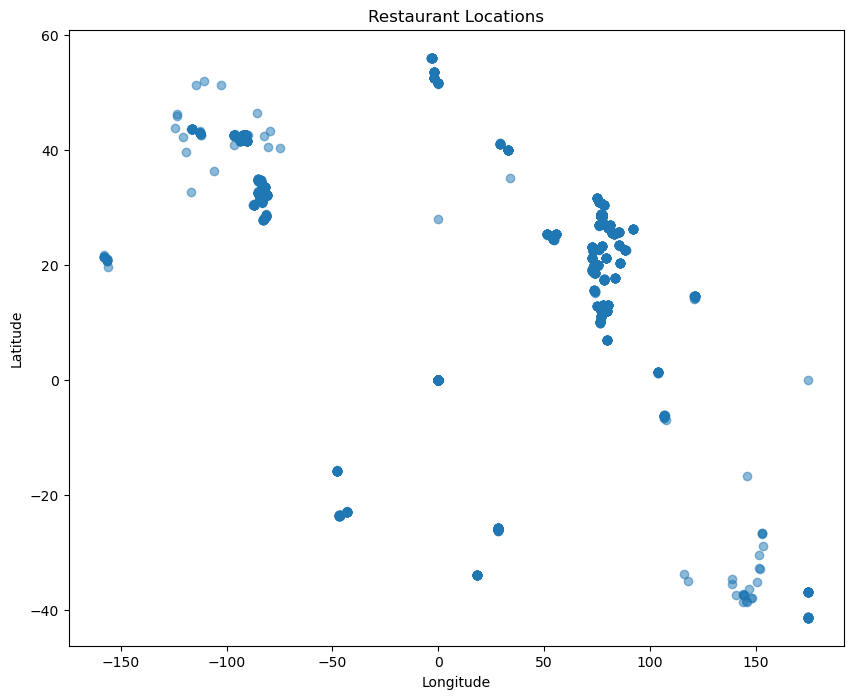

In [53]:
plt.figure(figsize=(10,8))

plt.scatter(
    geo_df['Longitude'],
    geo_df['Latitude'],
    alpha=0.5
)

plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

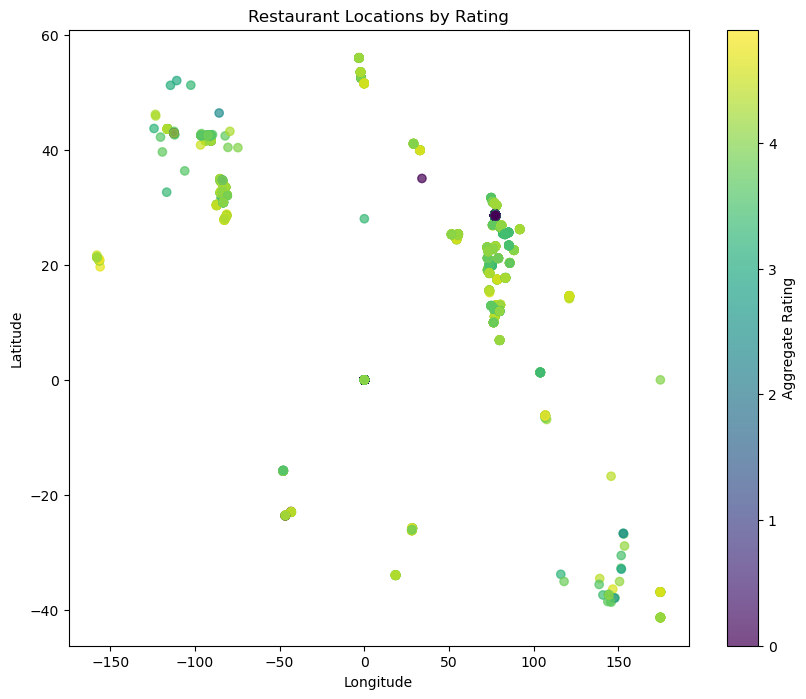

In [54]:
plt.figure(figsize=(10,8))

plt.scatter(
    geo_df['Longitude'],
    geo_df['Latitude'],
    c=geo_df['Aggregate rating'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(label='Aggregate Rating')

plt.title("Restaurant Locations by Rating")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [55]:
city_locations = geo_df.groupby('City').size().sort_values(ascending=False)

print(city_locations.head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Ahmedabad         21
Amritsar          21
dtype: int64


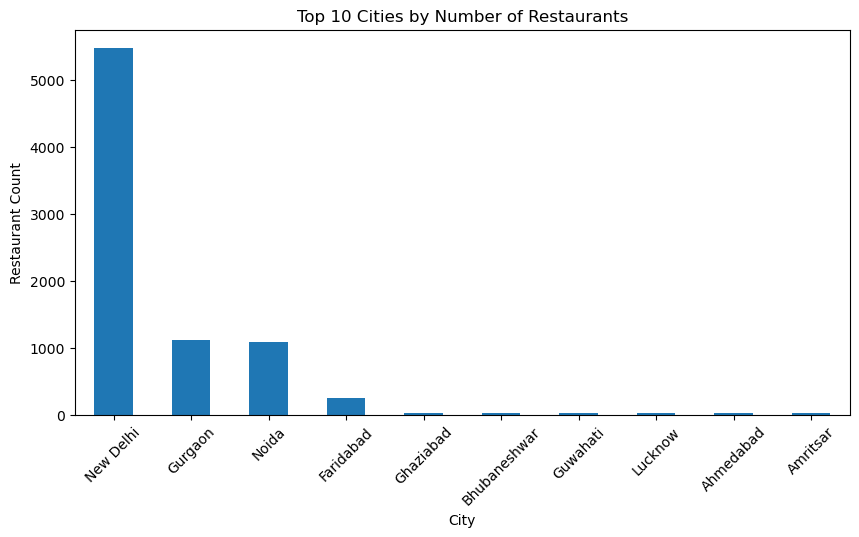

In [56]:
plt.figure(figsize=(10,5))

city_locations.head(10).plot(kind='bar')

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Restaurant Count")

plt.xticks(rotation=45)

plt.show()

In [57]:
print("Minimum Latitude :", geo_df['Latitude'].min())
print("Maximum Latitude :", geo_df['Latitude'].max())

print("Minimum Longitude:", geo_df['Longitude'].min())
print("Maximum Longitude:", geo_df['Longitude'].max())

Minimum Latitude : -41.330428
Maximum Latitude : 55.97698
Minimum Longitude: -157.948486
Maximum Longitude: 174.8320893


# Restaurant Chains Analysis

In [58]:
df[['Restaurant Name', 'Aggregate rating', 'Votes']].head()

,Restaurant Name,Aggregate rating,Votes
0,Le Petit Souffle,4.8,314
1,Izakaya Kikufuji,4.5,591
2,Heat - Edsa Shangri-La,4.4,270
3,Ooma,4.9,365
4,Sambo Kojin,4.8,229


In [59]:
restaurant_count = df['Restaurant Name'].value_counts()

print(restaurant_count.head(20))

Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
Keventers             34
Pizza Hut             30
Giani                 29
Baskin Robbins        28
Barbeque Nation       26
Giani's               22
Barista               22
Dunkin' Donuts        22
Costa Coffee          20
Pind Balluchi         20
Pizza Hut Delivery    19
Twenty Four Seven     19
Wah Ji Wah            19
Sagar Ratna           19
Starbucks             18
Name: count, dtype: int64


In [60]:
restaurant_chains = restaurant_count[restaurant_count > 1]

print(restaurant_chains)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
                    ..
Mithaas Sweets       2
Brown Town           2
Bikaner's            2
Adarsh Kulfi         2
Tea Trails           2
Name: count, Length: 734, dtype: int64


In [61]:
print("Total Restaurant Chains:", len(restaurant_chains))

Total Restaurant Chains: 734


In [62]:
chains_df = df[df['Restaurant Name'].isin(restaurant_chains.index)]

In [63]:
chain_rating = chains_df.groupby('Restaurant Name')['Aggregate rating'].mean()

chain_rating = chain_rating.sort_values(ascending=False)

print(chain_rating.head(10))

Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Garota de Ipanema            4.600
Dishoom                      4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64


In [64]:
chain_votes = chains_df.groupby('Restaurant Name')['Votes'].sum()

chain_votes = chain_votes.sort_values(ascending=False)

print(chain_votes.head(10))

Restaurant Name
Barbeque Nation              28142
AB's - Absolute Barbecues    13400
Big Chill                    10853
Farzi Cafe                   10098
Truffles                      9682
Chili's                       8156
Joey's Pizza                  7807
Big Yellow Door               7511
Saravana Bhavan               7238
Starbucks                     7139
Name: Votes, dtype: int64


In [65]:
chain_outlets = chains_df.groupby('Restaurant Name').size()

chain_outlets = chain_outlets.sort_values(ascending=False)

print(chain_outlets.head(10))

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
dtype: int64


In [66]:
chain_summary = chains_df.groupby('Restaurant Name').agg({
    'Aggregate rating':'mean',
    'Votes':'sum',
    'Restaurant Name':'count'
})

chain_summary.columns = [
    'Average Rating',
    'Total Votes',
    'Number of Outlets'
]

chain_summary = chain_summary.sort_values(
    by='Number of Outlets',
    ascending=False
)

print(chain_summary.head(10))

                  Average Rating  Total Votes  Number of Outlets
Restaurant Name                                                 
Cafe Coffee Day         2.419277         2428                 83
Domino's Pizza          2.740506         6643                 79
Subway                  2.907937         6124                 63
Green Chick Chop        2.672549          964                 51
McDonald's              3.339583         5291                 48
Keventers               2.870588         1263                 34
Pizza Hut               3.320000         4961                 30
Giani                   2.689655          854                 29
Baskin Robbins          1.860714          428                 28
Barbeque Nation         4.353846        28142                 26


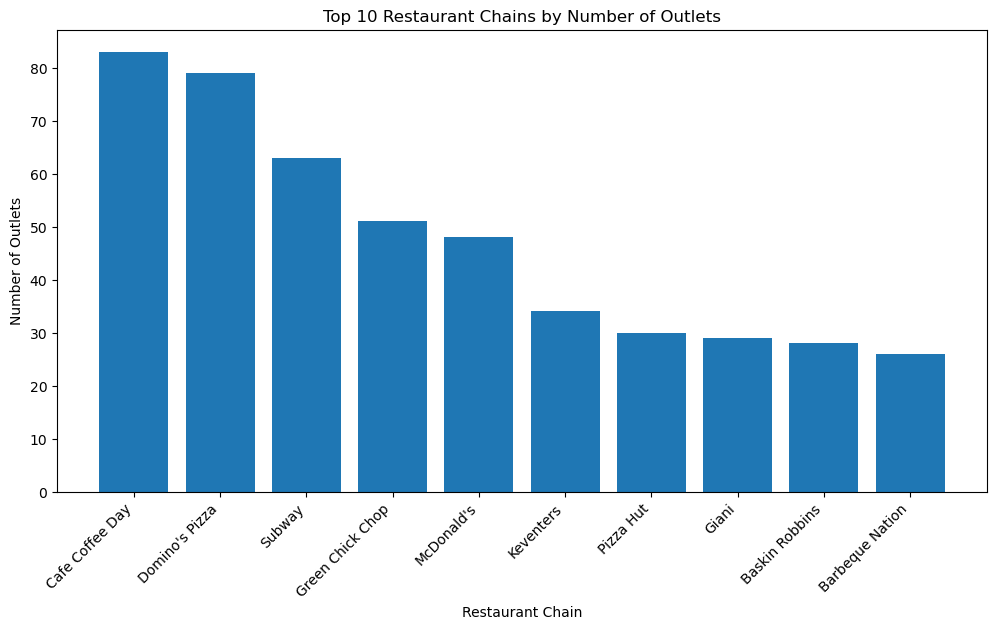

In [67]:
top10 = chain_summary.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10.index, top10['Number of Outlets'])

plt.title("Top 10 Restaurant Chains by Number of Outlets")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")

plt.xticks(rotation=45, ha='right')

plt.show()

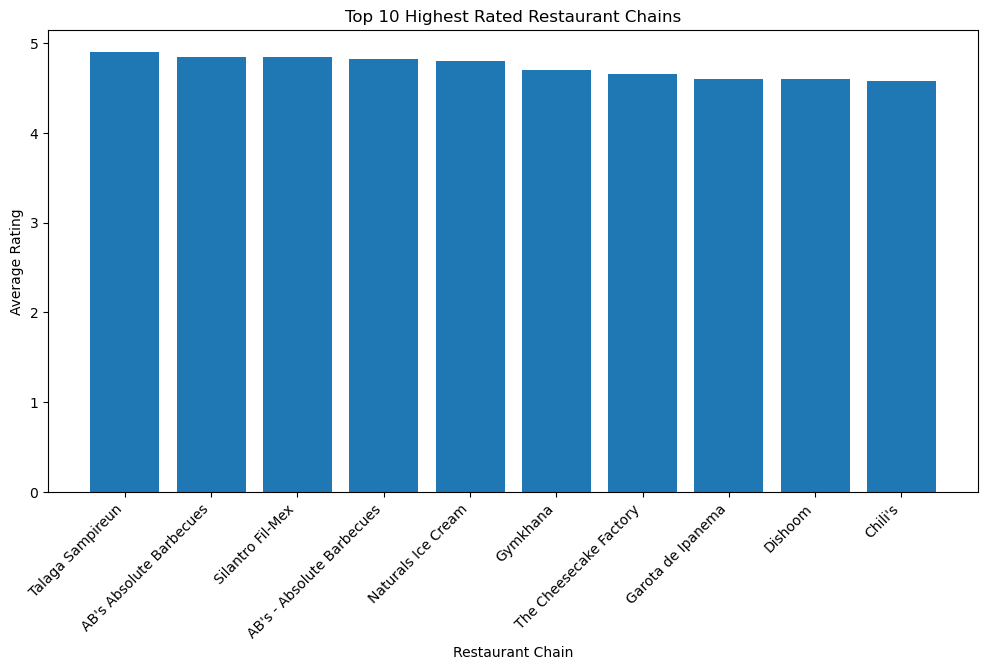

In [68]:
top_rated = chain_summary.sort_values(
    by='Average Rating',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_rated.index, top_rated['Average Rating'])

plt.title("Top 10 Highest Rated Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.ylabel("Average Rating")

plt.xticks(rotation=45, ha='right')

plt.show()

# Votes Analysis

In [69]:
df[['Restaurant Name', 'Votes', 'Aggregate rating']].head()

,Restaurant Name,Votes,Aggregate rating
0,Le Petit Souffle,314,4.8
1,Izakaya Kikufuji,591,4.5
2,Heat - Edsa Shangri-La,270,4.4
3,Ooma,365,4.9
4,Sambo Kojin,229,4.8


In [70]:
highest_votes = df.loc[df['Votes'].idxmax()]

print(highest_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

Restaurant Name      Toit
Votes               10934
Aggregate rating      4.8
Name: 728, dtype: object


In [71]:
lowest_votes = df.loc[df['Votes'].idxmin()]

print(lowest_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

Restaurant Name     Cantinho da Gula
Votes                              0
Aggregate rating                 0.0
Name: 69, dtype: object


In [72]:
top10_votes = df.nlargest(10, 'Votes')

print(top10_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

                Restaurant Name  Votes  Aggregate rating
728                        Toit  10934               4.8
735                    Truffles   9667               4.7
3994           Hauz Khas Social   7931               4.3
2412                  Peter Cat   7574               4.3
739   AB's - Absolute Barbecues   6907               4.6
2414            Barbeque Nation   5966               4.9
743                 Big Brewsky   5705               4.5
2307  AB's - Absolute Barbecues   5434               4.9
736             The Black Pearl   5385               4.1
2411                      BarBQ   5288               4.2


In [73]:
bottom10_votes = df.nsmallest(10, 'Votes')

print(bottom10_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

        Restaurant Name  Votes  Aggregate rating
69     Cantinho da Gula      0               0.0
874       The Chaiwalas      0               0.0
879  Fusion Food Corner      0               0.0
880       Punjabi Rasoi      0               0.0
887       Baskin Robbin      0               0.0
900              Angaar      0               0.0
901               TcozY      0               0.0
902       The Retriever      0               0.0
905      Chill 'N Grill      0               0.0
906  Punjabi Restaurant      0               0.0


In [74]:
correlation = df['Votes'].corr(df['Aggregate rating'])

print("Correlation:", round(correlation, 2))

Correlation: 0.31


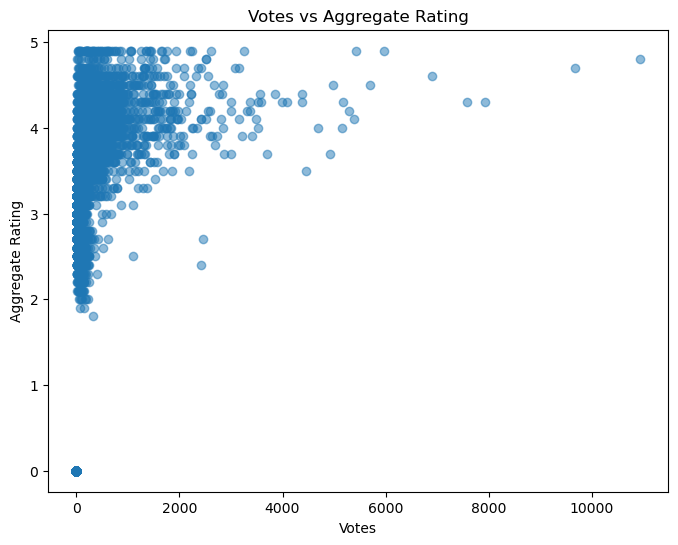

In [75]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Votes'],
    df['Aggregate rating'],
    alpha=0.5
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.show()

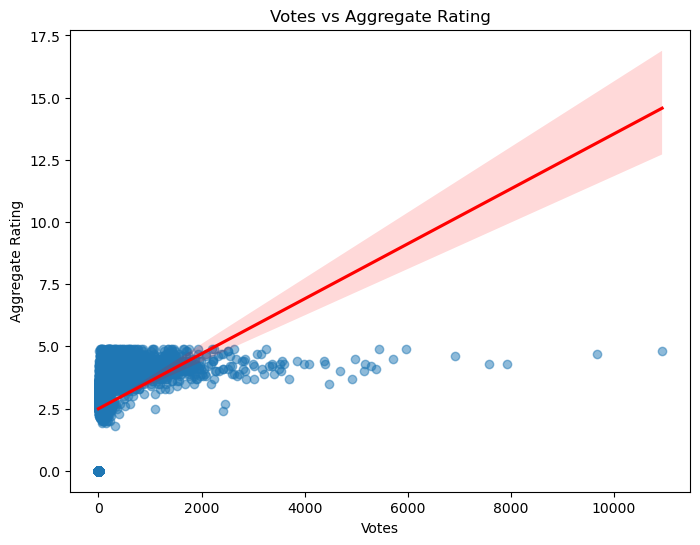

In [76]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='Votes',
    y='Aggregate rating',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.show()

In [77]:
print("Average Votes:", df['Votes'].mean())
print("Maximum Votes:", df['Votes'].max())
print("Minimum Votes:", df['Votes'].min())

Average Votes: 156.7720603647034
Maximum Votes: 10934
Minimum Votes: 0


# Price Range vs. Online Delivery and Table Booking

In [78]:
df[['Price range', 'Has Online delivery', 'Has Table booking']].head()

,Price range,Has Online delivery,Has Table booking
0,3,No,Yes
1,3,No,Yes
2,4,No,Yes
3,4,No,No
4,4,No,Yes


In [79]:
online_delivery = pd.crosstab(
    df['Price range'],
    df['Has Online delivery']
)

print(online_delivery)

Has Online delivery    No   Yes
Price range                    
1                    3737   701
2                    1827  1286
3                     994   411
4                     533    53


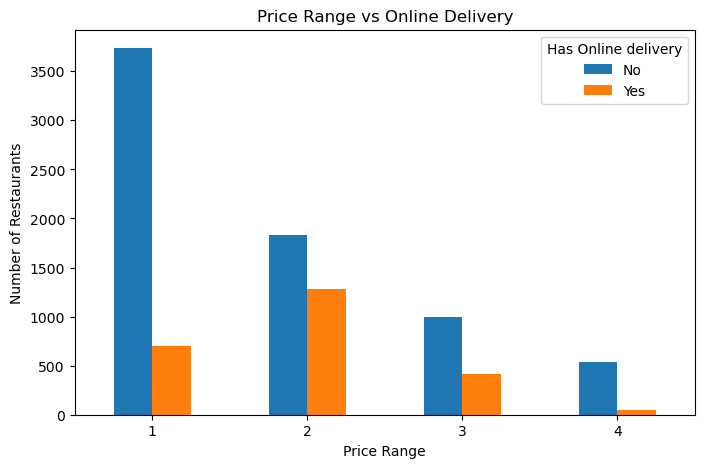

In [80]:
online_delivery.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Price Range vs Online Delivery")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)

plt.show()

In [81]:
online_percentage = pd.crosstab(
    df['Price range'],
    df['Has Online delivery'],
    normalize='index'
) * 100

print(online_percentage.round(2))

Has Online delivery     No    Yes
Price range                      
1                    84.20  15.80
2                    58.69  41.31
3                    70.75  29.25
4                    90.96   9.04


In [82]:
table_booking = pd.crosstab(
    df['Price range'],
    df['Has Table booking']
)

print(table_booking)

Has Table booking    No  Yes
Price range                 
1                  4437    1
2                  2874  239
3                   761  644
4                   312  274


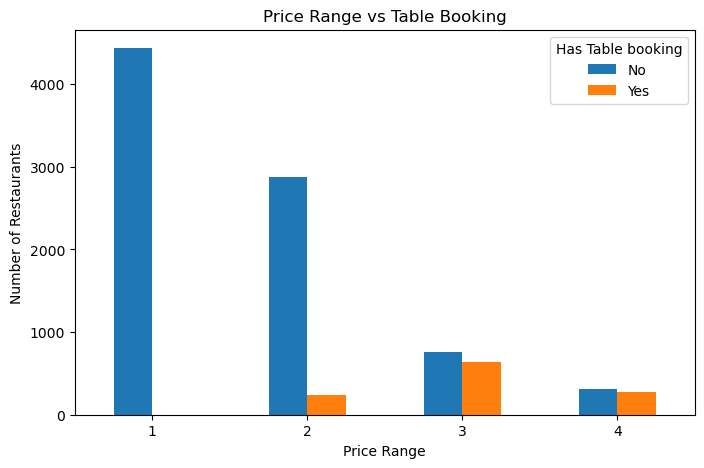

In [83]:
table_booking.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Price Range vs Table Booking")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)

plt.show()

In [84]:
table_percentage = pd.crosstab(
    df['Price range'],
    df['Has Table booking'],
    normalize='index'
) * 100

print(table_percentage.round(2))

Has Table booking     No    Yes
Price range                    
1                  99.98   0.02
2                  92.32   7.68
3                  54.16  45.84
4                  53.24  46.76


In [85]:
service_summary = df.groupby('Price range').agg({
    'Has Online delivery': lambda x: (x == 'Yes').mean() * 100,
    'Has Table booking': lambda x: (x == 'Yes').mean() * 100
})

service_summary.columns = [
    'Online Delivery (%)',
    'Table Booking (%)'
]

print(service_summary.round(2))

             Online Delivery (%)  Table Booking (%)
Price range                                        
1                          15.80               0.02
2                          41.31               7.68
3                          29.25              45.84
4                           9.04              46.76


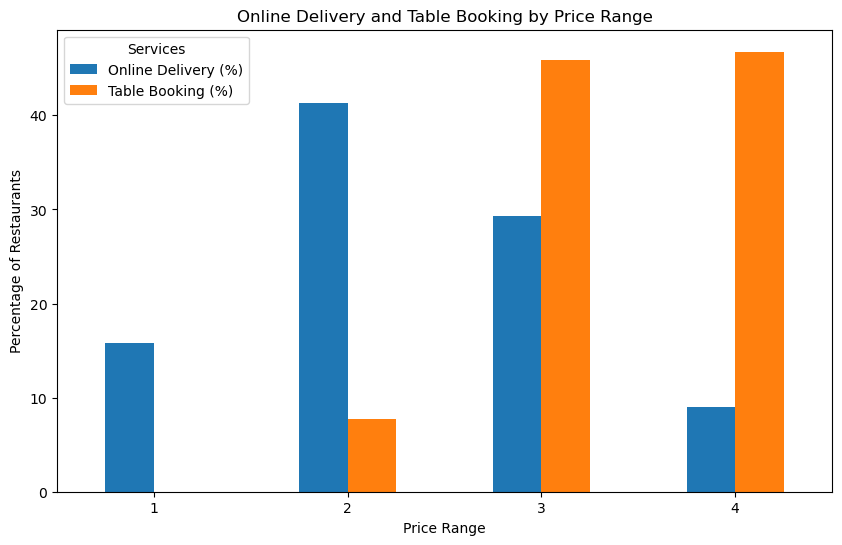

In [86]:
service_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Online Delivery and Table Booking by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants")

plt.xticks(rotation=0)

plt.legend(title="Services")

plt.show()

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   object 
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   object 
 4   Address               9542 non-null   object 
 5   Locality              9542 non-null   object 
 6   Locality Verbose      9542 non-null   object 
 7   Longitude             9542 non-null   float64
 8   Latitude              9542 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9542 non-null   int64  
 11  Currency              9542 non-null   object 
 12  Has Table booking     9542 non-null   object 
 13  Has Online delivery   9542 non-null   object 
 14  Is delivering now     9542 non-null   object 
 15  Switch to order menu  9542